# Phase 2: Market Segmentation via Clustering

In this notebook, you will:
1. Apply K-Means clustering to segment properties into market tiers
2. Use Hierarchical clustering and create dendrograms
3. Implement DBSCAN for density-based property grouping
4. Apply PCA for dimensionality reduction and visualization
5. Determine optimal clusters using Elbow method and Silhouette score
6. Interpret and visualize market segments

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.clustering import *

## 1. Data Preparation

In [2]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Features shape: {X_scaled.shape}")
print(f"Feature names: {feature_names}")

Features shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 2. K-Means Clustering

### Finding Optimal K

Best k by silhouette score: 2


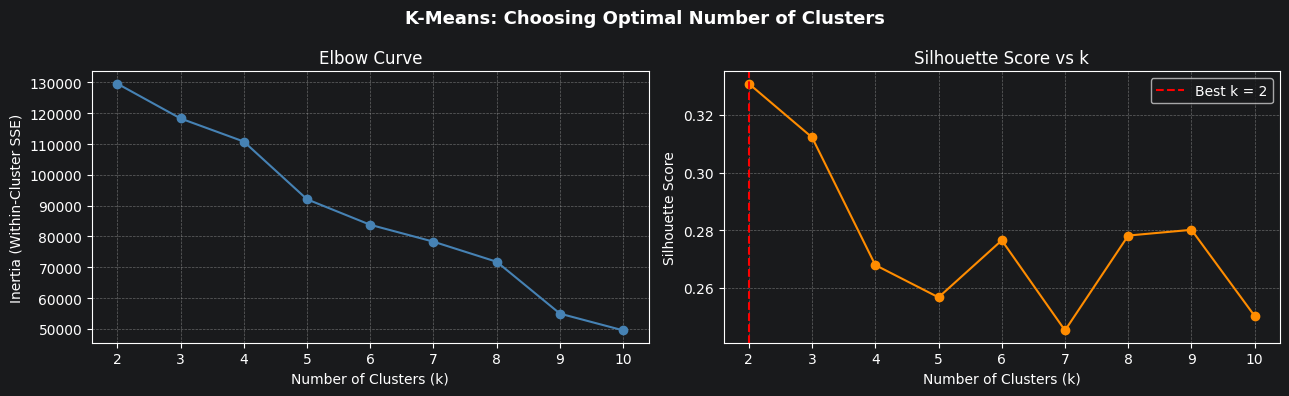

In [3]:

# --- Find Optimal K ---
k_results = find_optimal_k(X_scaled, k_range=range(2, 11))

best_k = k_results['best_k_silhouette']
print(f"Best k by silhouette score: {best_k}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow curve
axes[0].plot(k_results['k_range'], k_results['inertias'], marker='o', color='steelblue')
axes[0].set_title('Elbow Curve')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Silhouette scores
axes[1].plot(k_results['k_range'], k_results['silhouette_scores'], marker='o', color='darkorange')
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('K-Means: Choosing Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


K-Means Results (k=2)
  Inertia:         129,613.2
  Silhouette:      0.3308

Cluster sizes:
Cluster
0    11963
1     8677

Cluster profiles (mean feature values):
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
Cluster                                                                                               
0         3.918    28.413     5.225      1.076    1532.242     3.098    33.946    -118.01        2.138
1         3.805    28.952     5.710      1.126    1278.280     3.033    37.957    -121.72        1.972


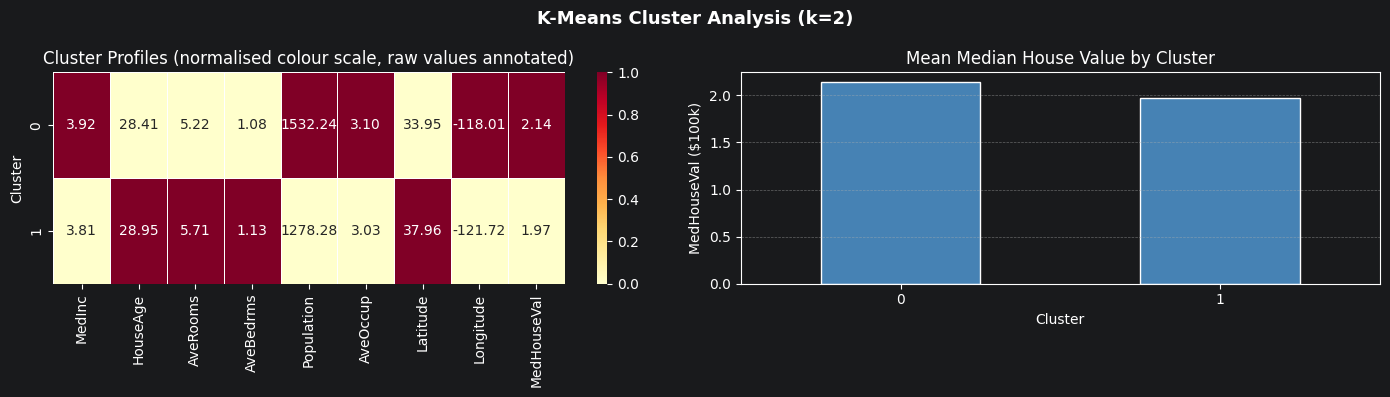

In [4]:

# --- K-Means with Optimal K ---
km_result = perform_kmeans(X_scaled, n_clusters=best_k)

print(f"K-Means Results (k={best_k})")
print(f"  Inertia:         {km_result['inertia']:,.1f}")
print(f"  Silhouette:      {km_result['silhouette']:.4f}")

# Attach cluster labels and target to a DataFrame for analysis
df_clusters = df.copy()
df_clusters['Cluster'] = km_result['labels']

# --- Cluster sizes ---
cluster_sizes = df_clusters['Cluster'].value_counts().sort_index()
print(f"\nCluster sizes:")
print(cluster_sizes.to_string())

# --- Cluster profiles: mean of each feature per cluster ---
profile_cols = feature_names + ['MedHouseVal']
cluster_profiles = df_clusters.groupby('Cluster')[profile_cols].mean().round(3)
print(f"\nCluster profiles (mean feature values):")
print(cluster_profiles.to_string())

# --- Visualise cluster profiles as a heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Normalise each feature column to [0, 1] so the heatmap is comparable
profile_norm = (cluster_profiles - cluster_profiles.min()) / (
    cluster_profiles.max() - cluster_profiles.min()
)
sns.heatmap(
    profile_norm,
    annot=cluster_profiles.values,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Cluster Profiles (normalised colour scale, raw values annotated)')
axes[0].set_ylabel('Cluster')

# Bar chart: median house value per cluster
cluster_profiles['MedHouseVal'].plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Mean Median House Value by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('MedHouseVal ($100k)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(f'K-Means Cluster Analysis (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Hierarchical Clustering

Dendrogram cut height for 2 clusters: 14.145


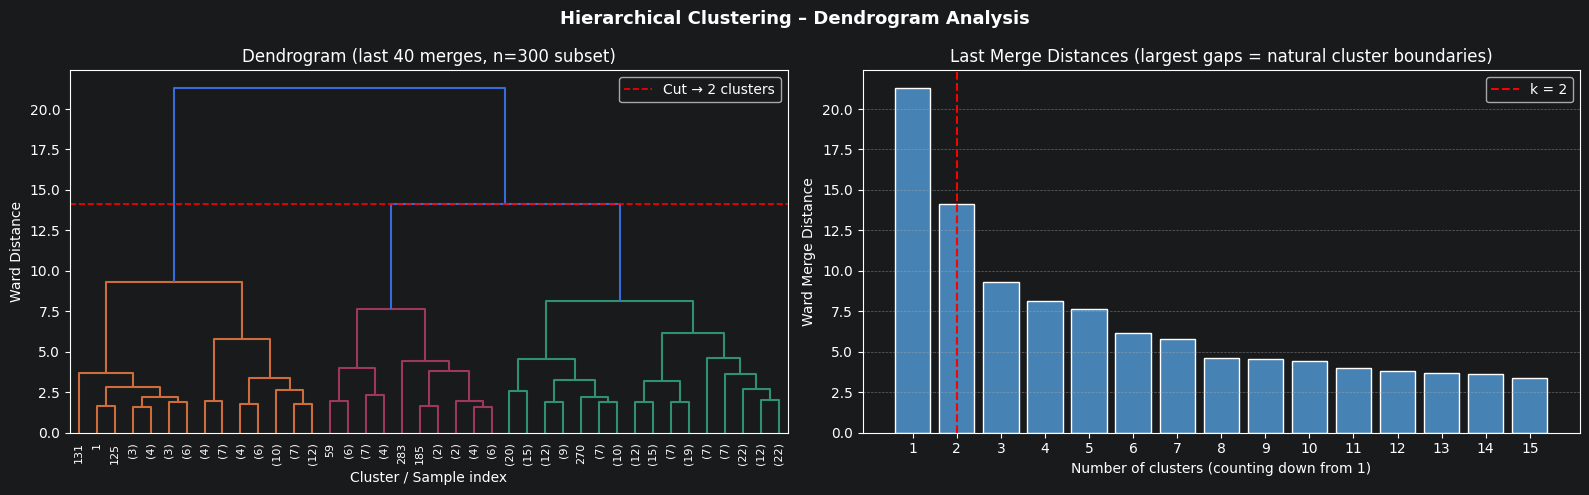

In [5]:

# --- Dendrogram on a subset for visualization ---
# Full dataset (20,640 rows) is too large for a readable dendrogram;
# a representative sample of 300 rows keeps it legible.
SUBSET_SIZE = 300
X_subset = X_scaled[:SUBSET_SIZE]

Z = compute_linkage_matrix(X_subset, method='ward')

# Height of the cut that produces best_k clusters:
# The linkage matrix rows are ordered by merge sequence.
# The (n - best_k)-th merge is the last one that still leaves best_k clusters.
cut_height = Z[-(best_k), 2]  # height just below the merge that reduces to best_k-1 clusters
print(f"Dendrogram cut height for {best_k} clusters: {cut_height:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: truncated dendrogram (last 40 merges) ---
dendrogram(
    Z,
    truncate_mode='lastp',
    p=40,
    color_threshold=cut_height,
    ax=axes[0],
    leaf_rotation=90,
    leaf_font_size=8,
)
axes[0].axhline(y=cut_height, color='red', linestyle='--', linewidth=1.2,
                label=f'Cut → {best_k} clusters')
axes[0].set_title(f'Dendrogram (last 40 merges, n={SUBSET_SIZE} subset)')
axes[0].set_xlabel('Cluster / Sample index')
axes[0].set_ylabel('Ward Distance')
axes[0].legend()

# --- Right: last-merges distance plot (scree-style) to show where the big jumps are ---
merge_distances = Z[:, 2]
last_n = 15
axes[1].bar(range(1, last_n + 1), merge_distances[-(last_n):][::-1],
            color='steelblue', edgecolor='white')
axes[1].axvline(x=best_k, color='red', linestyle='--',
                label=f'k = {best_k}')
axes[1].set_title('Last Merge Distances (largest gaps = natural cluster boundaries)')
axes[1].set_xlabel('Number of clusters (counting down from 1)')
axes[1].set_ylabel('Ward Merge Distance')
axes[1].set_xticks(range(1, last_n + 1))
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Hierarchical Clustering – Dendrogram Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Hierarchical Clustering Results (k=2, linkage=ward)
  Silhouette:  0.3213
  K-Means sil: 0.3308

Label agreement (cross-tabulation):
Hierarchical     0      1
K-Means                  
0               71  11892
1             7673   1004

Hierarchical cluster profiles (mean feature values):
            MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
HC_Cluster                                                                                               
0            3.761    29.378     5.781      1.149    1237.885     2.751    38.074   -121.854        2.014
1            3.937    28.196     5.218      1.065    1538.125     3.262    34.166   -118.198        2.102


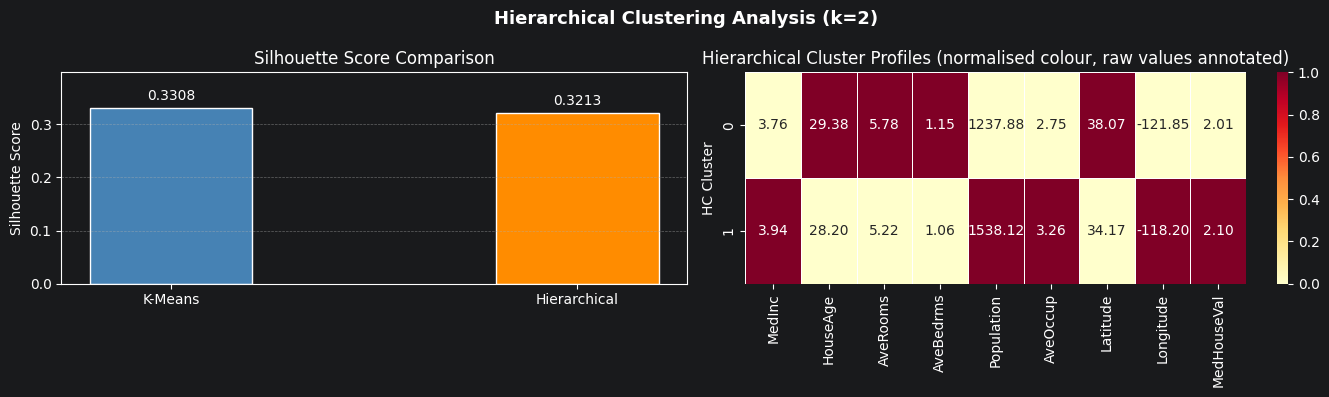

In [6]:

# --- Hierarchical clustering on the full dataset ---
hc_result = perform_hierarchical_clustering(X_scaled, n_clusters=best_k, linkage_method='ward')

print(f"Hierarchical Clustering Results (k={best_k}, linkage=ward)")
print(f"  Silhouette:  {hc_result['silhouette']:.4f}")
print(f"  K-Means sil: {km_result['silhouette']:.4f}")

# --- Label agreement: cross-tabulation of K-Means vs Hierarchical labels ---
agreement_df = pd.crosstab(
    km_result['labels'],
    hc_result['labels'],
    rownames=['K-Means'],
    colnames=['Hierarchical']
)
print(f"\nLabel agreement (cross-tabulation):")
print(agreement_df.to_string())

# --- Hierarchical cluster profiles ---
df_hc = df.copy()
df_hc['HC_Cluster'] = hc_result['labels']
hc_profiles = df_hc.groupby('HC_Cluster')[feature_names + ['MedHouseVal']].mean().round(3)
print(f"\nHierarchical cluster profiles (mean feature values):")
print(hc_profiles.to_string())

# --- Side-by-side silhouette comparison and profile heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Silhouette comparison bar chart
labels_bar = ['K-Means', 'Hierarchical']
scores_bar = [km_result['silhouette'], hc_result['silhouette']]
colors_bar = ['steelblue', 'darkorange']
bars = axes[0].bar(labels_bar, scores_bar, color=colors_bar, edgecolor='white', width=0.4)
axes[0].bar_label(bars, fmt='%.4f', padding=3)
axes[0].set_ylim(0, max(scores_bar) * 1.2)
axes[0].set_title('Silhouette Score Comparison')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Hierarchical cluster profiles heatmap
hc_norm = (hc_profiles - hc_profiles.min()) / (hc_profiles.max() - hc_profiles.min())
sns.heatmap(
    hc_norm,
    annot=hc_profiles.values,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Hierarchical Cluster Profiles (normalised colour, raw values annotated)')
axes[1].set_ylabel('HC Cluster')

plt.suptitle(f'Hierarchical Clustering Analysis (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. DBSCAN Clustering

In [ ]:

# --- Tune DBSCAN hyperparameters ---
eps_range       = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
min_samples_range = [5, 10, 20, 50]

tune_results = tune_dbscan(X_scaled, eps_range=eps_range, min_samples_range=min_samples_range)
tune_results['noise_pct'] = (tune_results['n_noise'] / len(X_scaled) * 100).round(1)

print("Full tuning grid results:")
print(tune_results.to_string(index=False))

# --- Select best parameters: ≥2 clusters, <10% noise, highest silhouette ---
valid = tune_results[
    (tune_results['n_clusters'] >= 2) &
    (tune_results['noise_pct'] < 10.0) &
    (tune_results['silhouette'].notna())
].copy()

best_row      = valid.loc[valid['silhouette'].idxmax()]
best_eps      = best_row['eps']
best_min_samp = int(best_row['min_samples'])

print(f"\nBest parameters → eps={best_eps}, min_samples={best_min_samp}")
print(f"  n_clusters: {int(best_row['n_clusters'])}  |  "
      f"noise: {int(best_row['n_noise'])} ({best_row['noise_pct']:.1f}%)  |  "
      f"silhouette: {best_row['silhouette']:.4f}")

# --- Heatmap: silhouette score across the grid ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sil_pivot = tune_results.pivot(index='min_samples', columns='eps', values='silhouette')
n_pivot   = tune_results.pivot(index='min_samples', columns='eps', values='n_clusters')

sns.heatmap(sil_pivot, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0], vmin=-0.5, vmax=1.0)
axes[0].set_title('Silhouette Score (NaN = fewer than 2 clusters)')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('min_samples')

sns.heatmap(n_pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Number of Clusters Found')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('min_samples')

plt.suptitle('DBSCAN Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:

# --- Run DBSCAN with best parameters ---
db_result = perform_dbscan(X_scaled, eps=best_eps, min_samples=best_min_samp)

print(f"DBSCAN Results (eps={best_eps}, min_samples={best_min_samp})")
print(f"  Clusters found:  {db_result['n_clusters']}")
print(f"  Noise points:    {db_result['n_noise']} "
      f"({db_result['n_noise'] / len(X_scaled) * 100:.1f}%)")
print(f"  Silhouette:      {db_result['silhouette']:.4f}")

# --- Cluster composition ---
db_labels = db_result['labels']
unique_labels = sorted(set(db_labels))
print(f"\nPoints per label (−1 = noise):")
for lbl in unique_labels:
    count = int((db_labels == lbl).sum())
    tag = 'noise' if lbl == -1 else f'cluster {lbl}'
    print(f"  {tag:12s}: {count:6d}  ({count / len(X_scaled) * 100:.1f}%)")

# --- Cluster profiles (non-noise points only) ---
df_db = df.copy()
df_db['DBSCAN_Label'] = db_labels
non_noise = df_db[df_db['DBSCAN_Label'] != -1]
db_profiles = non_noise.groupby('DBSCAN_Label')[feature_names + ['MedHouseVal']].mean().round(3)
print(f"\nCluster profiles (noise excluded):")
print(db_profiles.to_string())

# --- Silhouette comparison across all three algorithms ---
sil_scores = {
    'K-Means':      km_result['silhouette'],
    'Hierarchical': hc_result['silhouette'],
    'DBSCAN':       db_result['silhouette'],
}

# --- Visualise: 2-D PCA scatter + silhouette bar ---
from src.clustering import perform_pca

pca2 = perform_pca(X_scaled, n_components=2)
pca_data = pca2['transformed']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: clusters in colour, noise in grey
palette = {-1: '#cccccc'}  # noise = grey
cluster_ids = sorted(lbl for lbl in unique_labels if lbl != -1)
colors_c = plt.cm.tab10.colors
for i, lbl in enumerate(cluster_ids):
    palette[lbl] = colors_c[i % len(colors_c)]

for lbl in unique_labels:
    mask = db_labels == lbl
    label_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    alpha = 0.25 if lbl == -1 else 0.5
    size  = 2    if lbl == -1 else 4
    axes[0].scatter(
        pca_data[mask, 0], pca_data[mask, 1],
        c=palette[lbl], label=label_str,
        s=size, alpha=alpha, rasterized=True
    )
axes[0].set_title(f'DBSCAN Clusters in PCA Space\n(eps={best_eps}, min_samples={best_min_samp})')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')
axes[0].legend(markerscale=4, loc='best')

# Silhouette comparison bar
bar_colors = ['steelblue', 'darkorange', 'seagreen']
bars = axes[1].bar(sil_scores.keys(), sil_scores.values(),
                   color=bar_colors, edgecolor='white', width=0.4)
axes[1].bar_label(bars, fmt='%.4f', padding=3)
axes[1].set_ylim(0, max(sil_scores.values()) * 1.25)
axes[1].set_title('Silhouette Score Comparison (All Algorithms)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('DBSCAN Cluster Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. PCA & Visualization

In [ ]:
# TODO: Perform PCA and plot explained variance
# Find optimal number of components for 95% variance

In [ ]:
# TODO: Use cluster_with_pca() for 2D visualization
# Create scatter plot colored by cluster labels

## 6. Cluster Interpretation

TODO: For each cluster, analyze:
- Average feature values
- Price distribution
- Geographic distribution
- What "market tier" does each cluster represent?

In [ ]:
# TODO: Create cluster profile analysis

## Summary

TODO: Write a summary:
- Which clustering algorithm worked best for this data?
- How many natural market segments exist?
- What characterizes each segment?
- How did PCA help with visualization?